## Project Overview

The aim of this project is to improve the performance of a diabetes prediction model by applying feature engineering techniques.

The workflow includes:

- Exploratory Data Analysis (EDA)
- Missing Value Analysis
- Outlier Detection
- Feature Engineering
- Encoding
- Feature Scaling
- Model Building and Evaluation

Dataset: Pima Indians Diabetes Dataset
Target Variable: Outcome (0: Non-diabetic, 1: Diabetic)

## 1. Import Lıbraries

In [2]:
import sys

print(sys.executable)

/Users/zehrabetularslantas/Desktop/Miuul_ödevler/.venv/bin/python


In [4]:
#Data manipulation and analysis
import pandas as pd

#Numerical computations
import numpy as np

#Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Split dataset into train and test sets
from sklearn.model_selection import train_test_split

#Random forest classification model
from sklearn.ensemble import RandomForestClassifier

#Scale numerical features
from sklearn.preprocessing import StandardScaler

#Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#Handle file and folder paths
from pathlib import Path

#Encode binary categorical variables
from sklearn.preprocessing import LabelEncoder

# Model evaluation and hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Ignore warning messages for cleaner output
import warnings
warnings.simplefilter(action="ignore")


Notebook hazır 🚀


## 2. Display Settings

Configure pandas display options to make the dataset easier to inspect during the analysis.

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)


## 3. Load dataset

In [5]:
# Define dataset path
DATA_PATH = Path("diabetes.csv")

#Raise an error if the dataset is missing
if not DATA_PATH.exists():
    raise FileNotFoundError("diabetes.csv is not found. Please place the dataset in the same folder as the notebook.")

df = pd.read_csv(DATA_PATH)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


## 4. Initial Data Exploration

Define a reusable function to quickly inspect the structure and overall characteristics of a dataset.

In [12]:
def check_df(dataframe, head=5):
    """
    Display a quick overview of a pandas DataFrame.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to inspect.

    head : int, default=5
        Number of rows displayed from the beginning and end.
    """

    print("##################### Shape #####################")
    print(dataframe.shape)

    print("\n##################### Data Types #####################")
    print(dataframe.dtypes)

    print("\n##################### Head #####################")
    print(dataframe.head(head))

    print("\n##################### Tail #####################")
    print(dataframe.tail(head))

    print("\n##################### Missing Values #####################")
    missing = dataframe.isnull().sum()
    missing_percent = 100 * missing / len(dataframe)

    print(
        pd.DataFrame({
            "Missing": missing,
            "Missing %": missing_percent
        })
    )

    print("\n##################### Duplicated Rows #####################")
    print(dataframe.duplicated().sum())

    print("\n##################### Unique Values #####################")
    print(dataframe.nunique())

    print("\n##################### Quantiles #####################")
    print(
        dataframe.select_dtypes(include="number")
        .quantile([0, 0.05, 0.50, 0.95, 0.99, 1])
        .T
    )

check_df(df)

##################### Shape #####################
(768, 9)

##################### Data Types #####################
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

##################### Head #####################
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0            6      148             72             35        0 33.600   
1            1       85             66             29        0 26.600   
2            8      183             64              0        0 23.300   
3            1       89             66             23       94 28.100   
4            0      137             40             35      168 43.100   

   DiabetesPedigreeFunction  Age  Outcome  
0             

## 5. Identify Column Types

Classify features into categorical, numerical, and high-cardinality groups for efficient exploratory data analysis.

In [18]:
def grab_col_names(dataframe, cat_th=10, car_th=20, verbose=True):
    """
    Identify categorical, numerical, and high-cardinality categorical columns.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to inspect.

    cat_th : int, default=10
        Numerical columns with fewer unique values than this threshold
        are treated as categorical.

    car_th : int, default=20
        Categorical columns with more unique values than this threshold
        are treated as high-cardinality categorical variables.

    verbose : bool, default=True
        Print a summary of detected column types.

    Returns
    -------
    cat_cols : list
        Categorical columns, including numerical-but-categorical columns.

    num_cols : list
        Numerical columns.

    cat_but_car : list
        High-cardinality categorical columns.
    """

    # Detect columns with categorical-like data types
    categorical_cols = dataframe.select_dtypes(
        include=["object", "category", "string", "bool"]
    ).columns.tolist()

    # Numerical columns that behave like categorical variables
    num_but_cat = [
        col for col in dataframe.select_dtypes(include="number").columns
        if dataframe[col].nunique() < cat_th
    ]

    # Categorical columns with high cardinality
    cat_but_car = [
        col for col in categorical_cols
        if dataframe[col].nunique() > car_th
    ]

    # Final categorical columns
    cat_cols = categorical_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # Final numerical columns
    num_cols = dataframe.select_dtypes(include="number").columns.tolist()
    num_cols = [col for col in num_cols if col not in num_but_cat]

    if verbose:
        print("##################### Column Summary #####################")
        print(f"Observations       : {dataframe.shape[0]}")
        print(f"Variables          : {dataframe.shape[1]}")
        print(f"Categorical        : {len(cat_cols)}")
        print(f"Numerical          : {len(num_cols)}")
        print(f"High Cardinality   : {len(cat_but_car)}")
        print(f"Num but Categorical: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

##################### Column Summary #####################
Observations       : 768
Variables          : 9
Categorical        : 1
Numerical          : 8
High Cardinality   : 0
Num but Categorical: 1


## 6. Analyze Categorical Variables

Create reusable functions to summarize and visualize categorical features.

In [20]:
def cat_summary(dataframe, col_name, plot=False):
    """
    Display frequency and ratio of a categorical feature.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to analyze.

    col_name : str
        Name of the categorical column.

    plot : bool, default=False
        If True, display a count plot.
    """

    summary_df = pd.DataFrame({
        "Count": dataframe[col_name].value_counts(),
        "Ratio (%)": 100 * dataframe[col_name].value_counts(normalize=True)
    })

    print(summary_df)
    print("#" * 50)

    if plot:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=col_name, data=dataframe)

        plt.title(f"Distribution of {col_name}")
        plt.xlabel(col_name)
        plt.ylabel("Count")

        plt.tight_layout()
        plt.show()

cat_summary(df, "Outcome")

         Count  Ratio (%)
Outcome                  
0          500     65.104
1          268     34.896
##################################################


## 7. Analyze Numerical Variables

Summarize numerical features using descriptive statistics, percentiles, and distribution plots.

count   768.000
mean      3.845
std       3.370
min       0.000
5%        0.000
10%       0.000
20%       1.000
30%       1.000
40%       2.000
50%       3.000
60%       4.000
70%       5.000
80%       7.000
90%       9.000
95%      10.000
99%      13.000
max      17.000
Name: Pregnancies, dtype: float64


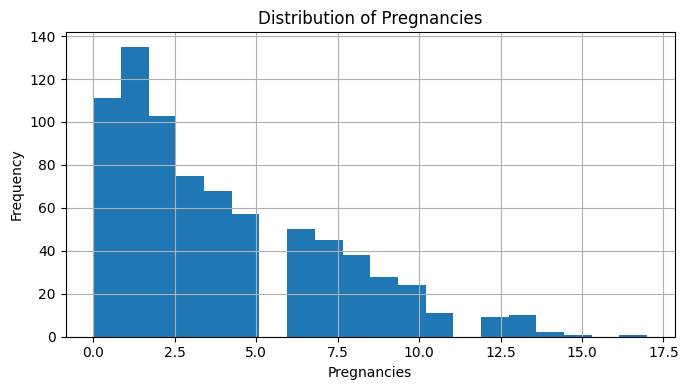

count   768.000
mean    120.895
std      31.973
min       0.000
5%       79.000
10%      85.000
20%      95.000
30%     102.000
40%     109.000
50%     117.000
60%     125.000
70%     134.000
80%     147.000
90%     167.000
95%     181.000
99%     196.000
max     199.000
Name: Glucose, dtype: float64


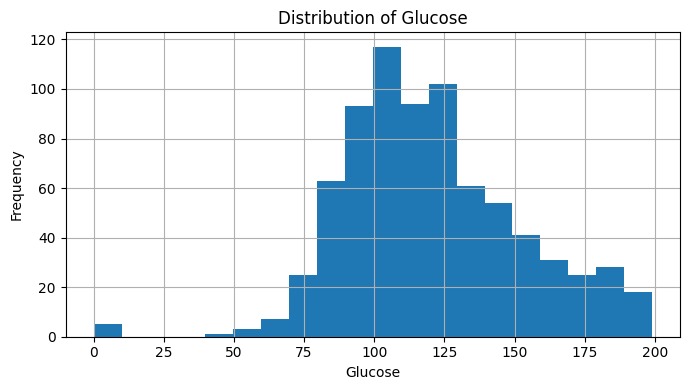

count   768.000
mean     69.105
std      19.356
min       0.000
5%       38.700
10%      54.000
20%      60.000
30%      64.000
40%      68.000
50%      72.000
60%      74.000
70%      78.000
80%      82.000
90%      88.000
95%      90.000
99%     106.000
max     122.000
Name: BloodPressure, dtype: float64


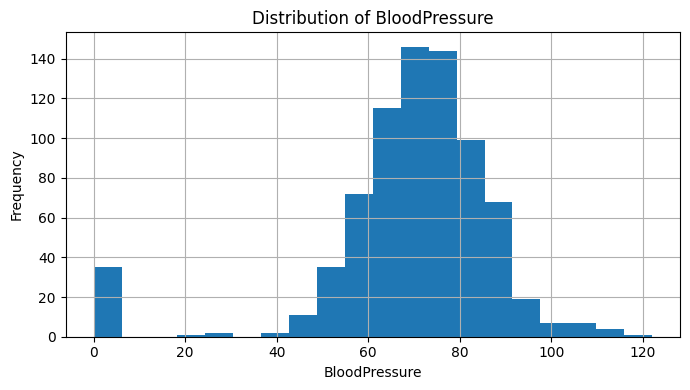

count   768.000
mean     20.536
std      15.952
min       0.000
5%        0.000
10%       0.000
20%       0.000
30%       8.200
40%      18.000
50%      23.000
60%      27.000
70%      31.000
80%      35.000
90%      40.000
95%      44.000
99%      51.330
max      99.000
Name: SkinThickness, dtype: float64


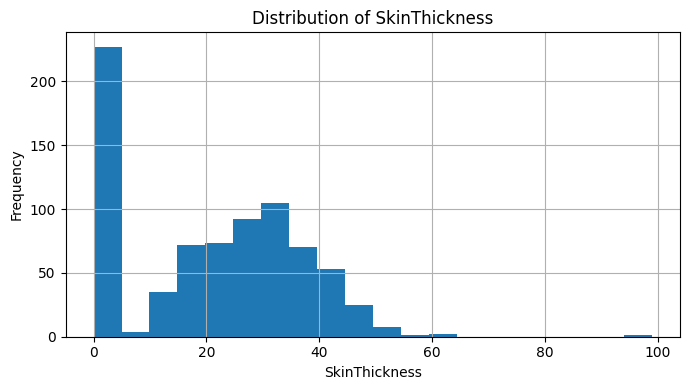

count   768.000
mean     79.799
std     115.244
min       0.000
5%        0.000
10%       0.000
20%       0.000
30%       0.000
40%       0.000
50%      30.500
60%      72.200
70%     106.000
80%     150.000
90%     210.000
95%     293.000
99%     519.900
max     846.000
Name: Insulin, dtype: float64


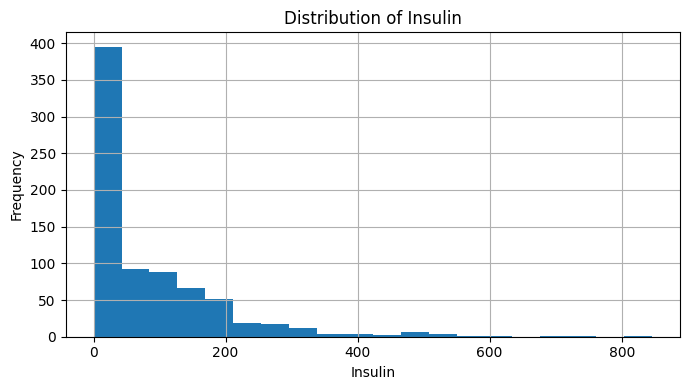

count   768.000
mean     31.993
std       7.884
min       0.000
5%       21.800
10%      23.600
20%      25.900
30%      28.200
40%      30.100
50%      32.000
60%      33.700
70%      35.490
80%      37.800
90%      41.500
95%      44.395
99%      50.759
max      67.100
Name: BMI, dtype: float64


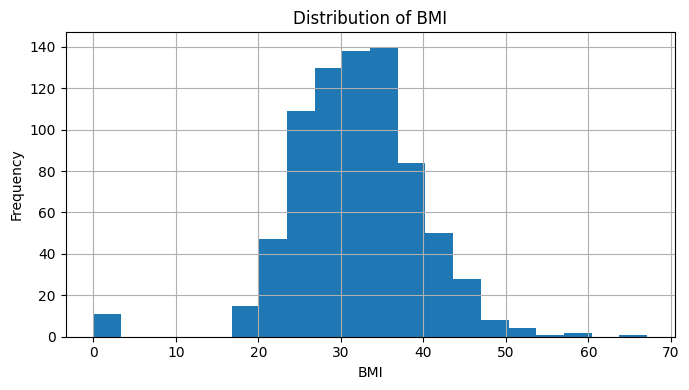

count   768.000
mean      0.472
std       0.331
min       0.078
5%        0.140
10%       0.165
20%       0.219
30%       0.259
40%       0.303
50%       0.372
60%       0.454
70%       0.564
80%       0.687
90%       0.879
95%       1.133
99%       1.698
max       2.420
Name: DiabetesPedigreeFunction, dtype: float64


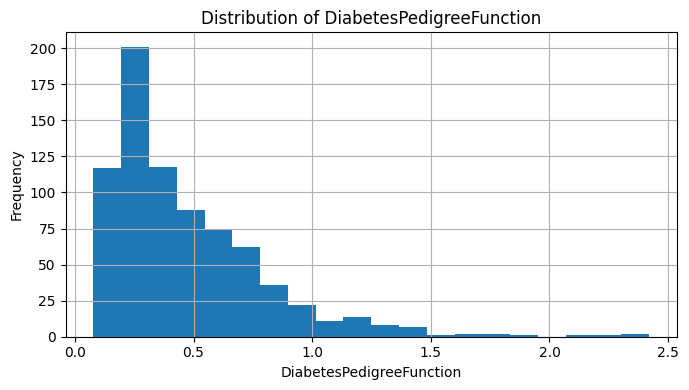

count   768.000
mean     33.241
std      11.760
min      21.000
5%       21.000
10%      22.000
20%      23.000
30%      25.000
40%      27.000
50%      29.000
60%      33.000
70%      38.000
80%      42.600
90%      51.000
95%      58.000
99%      67.000
max      81.000
Name: Age, dtype: float64


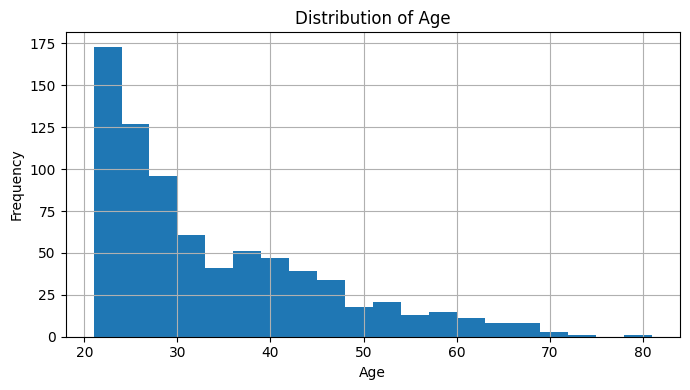

In [21]:
def num_summary(dataframe, numerical_col, plot=True):
    """
    Display descriptive statistics and optionally visualize
    the distribution of a numerical feature.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to analyze.

    numerical_col : str
        Name of the numerical column.

    plot : bool, default=True
        If True, display a histogram of the numerical feature.
    """

    quantiles = [
        0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
        0.60, 0.70, 0.80, 0.90, 0.95, 0.99
    ]

    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        plt.figure(figsize=(7, 4))
        dataframe[numerical_col].hist(bins=20)

        plt.xlabel(numerical_col)
        plt.ylabel("Frequency")
        plt.title(f"Distribution of {numerical_col}")

        plt.tight_layout()
        plt.show()

for col in num_cols:
    num_summary(df, col, plot=True)

## 8. Target Variable Analysis

Analyze the relationship between the target variable and numerical features.

In [22]:
def target_summary_with_num(dataframe, target, numerical_col):
    """
    Compare the mean of a numerical feature across target classes.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to analyze.

    target : str
        Target variable.

    numerical_col : str
        Numerical feature to summarize.
    """

    summary = (
        dataframe
        .groupby(target)
        .agg({numerical_col: "mean"})
        .round(2)
    )

    print(summary)
    print("#" * 50)

for col in num_cols: 
    target_summary_with_num(df, "Outcome", col)

         Pregnancies
Outcome             
0              3.300
1              4.870
##################################################
         Glucose
Outcome         
0        109.980
1        141.260
##################################################
         BloodPressure
Outcome               
0               68.180
1               70.820
##################################################
         SkinThickness
Outcome               
0               19.660
1               22.160
##################################################
         Insulin
Outcome         
0         68.790
1        100.340
##################################################
           BMI
Outcome       
0       30.300
1       35.140
##################################################
         DiabetesPedigreeFunction
Outcome                          
0                           0.430
1                           0.550
##################################################
           Age
Outcome       
0       31.19

## 9. Correlation Analysis

Examine relationships between numerical features to identify potential dependencies and multicollinearity.

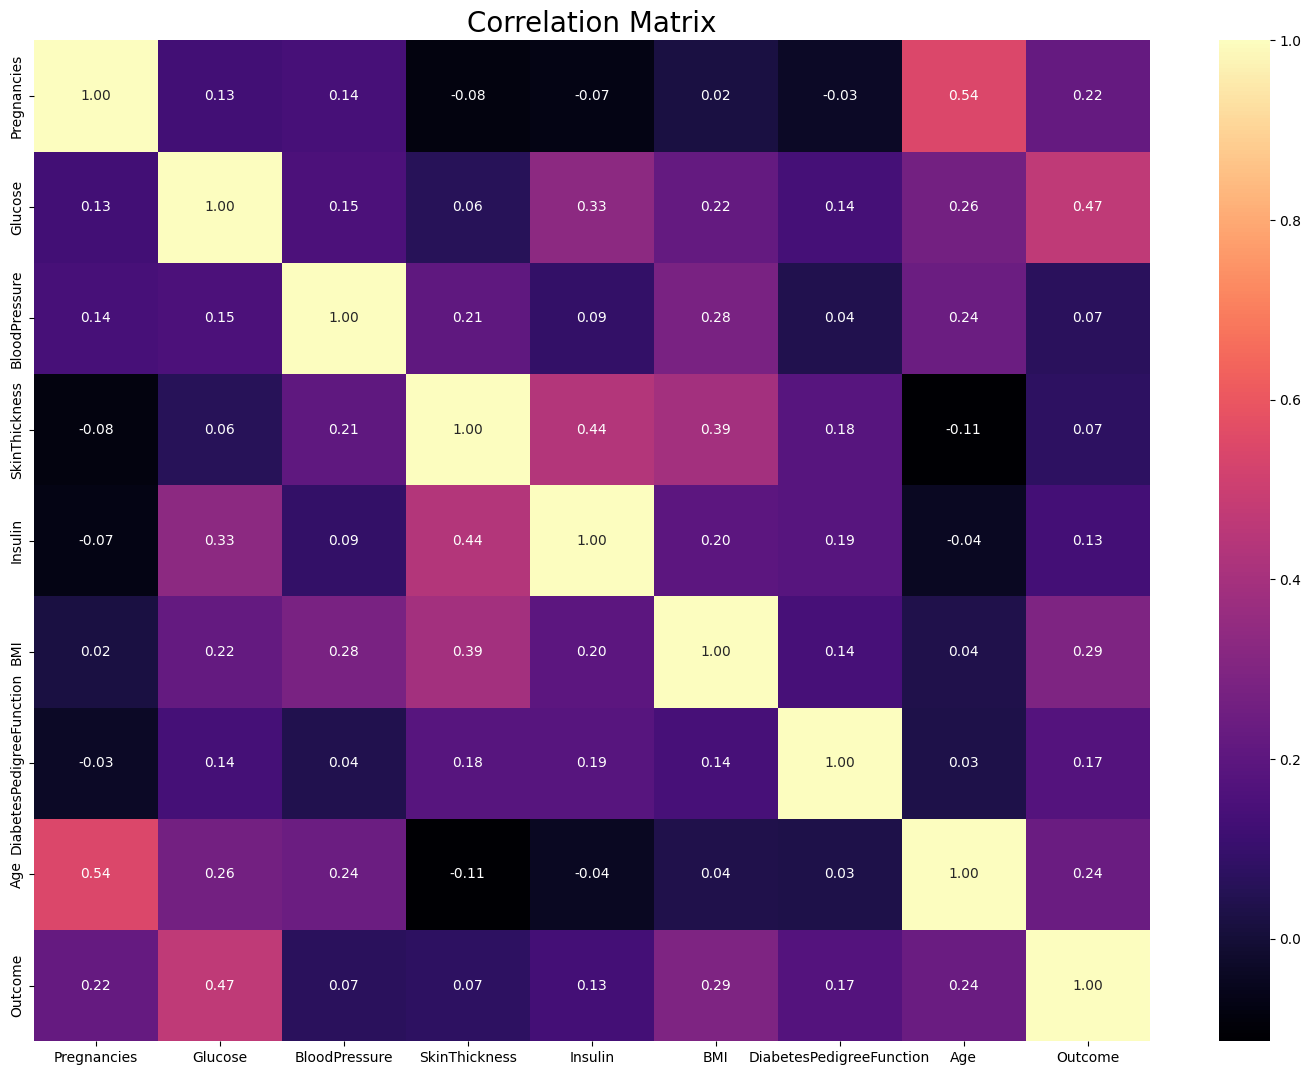

In [23]:
df.corr()

f, ax = plt.subplots(figsize=[18, 13])
sns.heatmap(df.corr(), annot=True, fmt=".2f", ax=ax, cmap="magma")
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()


### Key Findings

- Glucose has the strongest positive correlation with the target variable (Outcome).
- BMI, Age, and Pregnancies also show positive relationships with diabetes.
- Moderate correlations exist between Age–Pregnancies and SkinThickness–Insulin.
- No pair of features exhibits a very high correlation (>0.80), suggesting that multicollinearity is not a major concern at this stage.

## 10. Baseline Model

Train a baseline Random Forest model before applying feature engineering to establish a reference performance.

In [24]:
#Define the target variable
y = df["Outcome"]

#Define the feature matrix
X = df.drop("Outcome", axis=1)

#Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=17
)

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=46)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_pred):.3f}")

Accuracy : 0.771
Recall   : 0.593
Precision: 0.706
F1 Score : 0.644
ROC AUC  : 0.730


## 11. Feature Importance

Visualize feature importance scores to identify which variables contribute most to the baseline model.

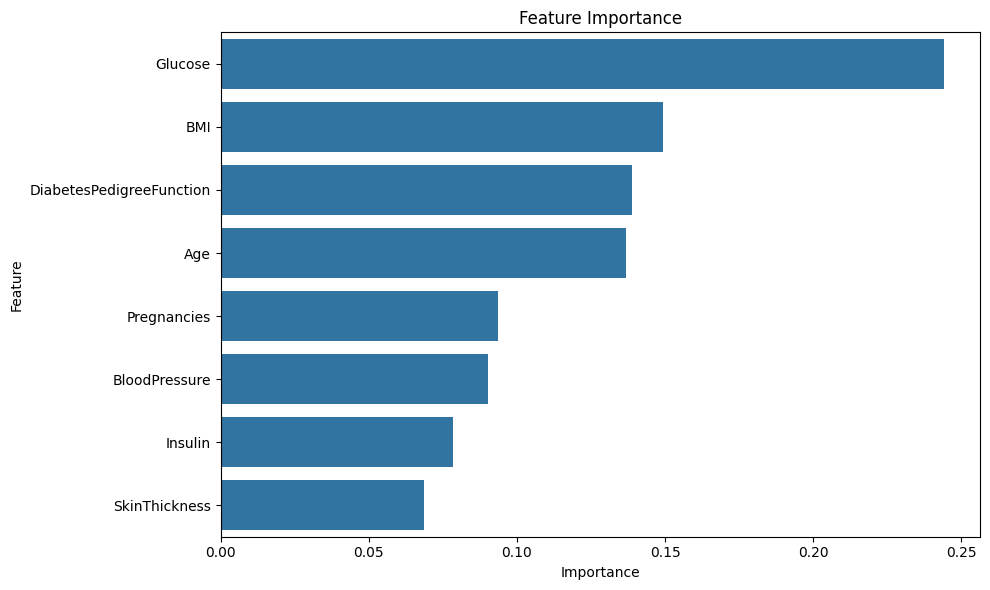

In [25]:
def plot_importance(model, features, num=None, save=False):
    """
    Plot feature importance scores for a trained tree-based model.

    Parameters
    ----------
    model : fitted model
        Trained model with a feature_importances_ attribute.

    features : pandas.DataFrame
        Feature matrix used to train the model.

    num : int, default=None
        Number of top features to display.
        If None, all features are shown.

    save : bool, default=False
        If True, save the plot as 'feature_importance.png'.
    """

    feature_imp = pd.DataFrame({
        "Value": model.feature_importances_,
        "Feature": features.columns
    })

    # Sort features by importance
    feature_imp = feature_imp.sort_values(
        by="Value",
        ascending=False
    )

    # Show all features if num is not specified
    if num is None:
        num = len(features.columns)

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x="Value",
        y="Feature",
        data=feature_imp.head(num)
    )

    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    if save:
        plt.savefig(
            "feature_importance.png",
            bbox_inches="tight"
        )

    plt.show()

plot_importance(rf_model, X)

## 12 Missing Value Analysis

Identify hidden missing values and prepare the dataset for feature engineering.

In [27]:
#columns where zero values are considered missing
zero_columns = [col for col in df.columns if (df[col].min() == 0 and col not in ["Pregnancies", "Outcome"])]

#Replace biologicalyy impossible zero values with NaN
for col in zero_columns:
    df[col] = np.where(df[col] == 0, np.nan, df[col])

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 13. Missing Value Summary

Summarize the number and percentage of missing values for each affected feature.

In [36]:
def missing_values_table(dataframe, na_name=False):
    """
    Summarize missing values by count and percentage.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to analyze.

    na_name : bool, default=False
        If True, return the names of columns containing missing values.
    """

    # Identify columns containing missing values
    na_columns = [
        col for col in dataframe.columns
        if dataframe[col].isnull().sum() > 0
    ]

    # Number of missing values
    n_miss = (
        dataframe[na_columns]
        .isnull()
        .sum()
        .sort_values(ascending=False)
    )

    # Percentage of missing values
    ratio = (
        dataframe[na_columns]
        .isnull()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    # Combine counts and percentages
    missing_df = pd.concat(
        [n_miss, ratio.round(2)],
        axis=1,
        keys=["n_miss", "ratio"]
    )

    print(missing_df)

    if na_name:
        return na_columns
    
na_columns = missing_values_table(df, na_name = True)

               n_miss  ratio
Insulin           374 48.700
SkinThickness     227 29.560
BloodPressure      35  4.560
BMI                11  1.430
Glucose             5  0.650


## 14. Missing Values vs Target

Investigate whether missing values are associated with the target variable.

In [37]:
def missing_vs_target(dataframe, target, na_columns):
    """
    Analyze whether missing values are related to the target variable.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to analyze.

    target : str
        Target variable.

    na_columns : list
        Columns containing missing values.
    """

    temp_df = dataframe.copy()

    #Create missing value indicator variables
    for col in na_columns:
        temp_df[f"{col}_NA_FLAG"] = np.where(
            temp_df[col].isnull(),
            1,
            0
        )

    na_flags = [
        col for col in temp_df.columns
        if col.endswith("_NA_FLAG")
    ]

    for col in na_flags:

        summary = pd.DataFrame({
            "TARGET_MEAN": temp_df.groupby(col)[target].mean(),
            "Count": temp_df.groupby(col)[target].count()
        })

        print(f"\n{col}")
        print(summary)
        print("-" * 50)

missing_vs_target(df, "Outcome", na_columns)

    


Glucose_NA_FLAG
                 TARGET_MEAN  Count
Glucose_NA_FLAG                    
0                      0.349    763
1                      0.400      5
--------------------------------------------------

BloodPressure_NA_FLAG
                       TARGET_MEAN  Count
BloodPressure_NA_FLAG                    
0                            0.344    733
1                            0.457     35
--------------------------------------------------

SkinThickness_NA_FLAG
                       TARGET_MEAN  Count
SkinThickness_NA_FLAG                    
0                            0.333    541
1                            0.388    227
--------------------------------------------------

Insulin_NA_FLAG
                 TARGET_MEAN  Count
Insulin_NA_FLAG                    
0                      0.330    394
1                      0.369    374
--------------------------------------------------

BMI_NA_FLAG
             TARGET_MEAN  Count
BMI_NA_FLAG                    
0              

### Key Findings

- Missing values do not appear to have a very strong relationship with the target variable
- SkinThickness and Insulin show slightly higher diabetes rates when values are missing.
- Glucose and BMI contain too few missing observations to draw reliable conclusions.
- Overall, missingness itself does not seem to be a strong predictor of diabetes in this dataset.

## 15. Missing Value Imputation

Fill missing values using the median of each feature.

In [38]:
# Fill missing values with the median of each feature
for col in zero_columns:
    df.loc[df[col].isnull(), col] = df[col].median()

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 16. Outlier Detection

Define reusable functions to calculate outlier thresholds using the IQR method.

In [39]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):


    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)

    interquantile_range = quartile3 - quartile1

    low_limit = quartile1 - 1.5 * interquantile_range
    up_limit = quartile3 + 1.5 * interquantile_range

    return low_limit, up_limit

## 17. Outlier Handling

Detect and cap outliers using the IQR thresholds.

In [40]:
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)

    return dataframe[
        (dataframe[col_name] < low_limit) |
        (dataframe[col_name] > up_limit)
    ].shape[0] > 0

def replace_with_thresholds(dataframe, col_name, q1=0.05, q3=0.95):

    low_limit, up_limit = outlier_thresholds(
        dataframe,
        col_name,
        q1,
        q3
    )

    dataframe.loc[
        dataframe[col_name] < low_limit,
        col_name
    ] = low_limit

    dataframe.loc[
        dataframe[col_name] > up_limit,
        col_name
    ] = up_limit

for col in df.columns:
    print(col, check_outlier(df, col))
    if check_outlier(df, col):
        replace_with_thresholds(df,col)

Pregnancies False
Glucose False
BloodPressure False
SkinThickness True
Insulin True
BMI False
DiabetesPedigreeFunction False
Age False
Outcome False


In [41]:
for col in df.columns:
    print(col, check_outlier(df, col))

Pregnancies False
Glucose False
BloodPressure False
SkinThickness False
Insulin False
BMI False
DiabetesPedigreeFunction False
Age False
Outcome False


## 18. Feature Engineering

Create new categorical features and interaction terms using age, BMI, and glucose levels.

In [47]:
# Create age categories
df.loc[
    (df["Age"] >= 21) & (df["Age"] < 50),
    "NEW_AGE_CAT"
] = "mature"

df.loc[
    df["Age"] >= 50,
    "NEW_AGE_CAT"
] = "senior"


# Create BMI categories
df["NEW_BMI"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 24.9, 29.9, float("inf")],
    labels=["underweight", "healthy", "overweight", "obese"]
)


# Create glucose categories
df["NEW_GLUCOSE"] = pd.cut(
    df["Glucose"],
    bins=[0, 70, 100, 126, float("inf")],
    labels=["low", "normal", "prediabetes", "diabetes"],
    right=False
)


# Create age-BMI interaction
df["NEW_AGE_BMI"] = (
    df["NEW_BMI"].astype(str)
    + "_"
    + df["NEW_AGE_CAT"].astype(str)
)


# Create age-glucose interaction
df["NEW_AGE_GLUCOSE"] = (
    df["NEW_GLUCOSE"].astype(str)
    + "_"
    + df["NEW_AGE_CAT"].astype(str)
)


# Create insulin category
df["NEW_INSULIN_SCORE"] = np.where(
    df["Insulin"].between(16, 166),
    "normal",
    "abnormal"
)


# Create numerical interaction features
df["NEW_GLUCOSE_X_INSULIN"] = (
    df["Glucose"] * df["Insulin"]
)

df["NEW_GLUCOSE_X_PREGNANCIES"] = (
    df["Glucose"] * df["Pregnancies"]
)


# Standardize column names
df.columns = [col.upper() for col in df.columns]


# Check the engineered features
df.head()

KeyError: 'Age'

## 19. Encoding Categorical Features

Convert categorical variables into numerical representations that machine learning models can understand.

In [48]:
cat_cols, num_cols, cat_but_car = grab_col_names(df)

##################### Column Summary #####################
Observations       : 768
Variables          : 17
Categorical        : 7
Numerical          : 10
High Cardinality   : 0
Num but Categorical: 1


## 19.2 Label Encoding

Encode binary categorical features into numerical values

In [49]:
def label_encoder(dataframe, binary_col):

    encoder = LabelEncoder()

    dataframe[binary_col] = encoder.fit_transform(
        dataframe[binary_col]
    )

    return dataframe

In [50]:
binary_cols = [
    col
    for col in df.select_dtypes(
        include=["object", "string"]
    ).columns
    if df[col].nunique(dropna=False) == 2
]

In [51]:
for col in binary_cols:
    df = label_encoder(df, col)

In [52]:
binary_cols

['NEW_AGE_CAT', 'NEW_INSULIN_SCORE']

### 19.3 One-Hot Encoding

Apply one-hot encoding to categorical variables with more than two categories.

In [53]:
cat_cols = [col for col in cat_cols if col not in binary_cols and col not in ["OUTCOME"]]
cat_cols

['NEW_BMI', 'NEW_GLUCOSE', 'NEW_AGE_BMI', 'NEW_AGE_GLUCOSE']

In [54]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

In [55]:
df = one_hot_encoder(df, cat_cols, drop_first=True)

df.head()

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME,NEW_AGE_CAT,NEW_INSULIN_SCORE,NEW_GLUCOSE_X_INSULIN,NEW_GLUCOSE_X_PREGNANCIES,NEW_BMI_healthy,NEW_BMI_overweight,NEW_BMI_obese,NEW_GLUCOSE_normal,NEW_GLUCOSE_prediabetes,NEW_GLUCOSE_diabetes,NEW_AGE_BMI_healthy_senior,NEW_AGE_BMI_obese_mature,NEW_AGE_BMI_obese_senior,NEW_AGE_BMI_overweight_mature,NEW_AGE_BMI_overweight_senior,NEW_AGE_BMI_underweight_mature,NEW_AGE_GLUCOSE_diabetes_senior,NEW_AGE_GLUCOSE_low_mature,NEW_AGE_GLUCOSE_low_senior,NEW_AGE_GLUCOSE_normal_mature,NEW_AGE_GLUCOSE_normal_senior,NEW_AGE_GLUCOSE_prediabetes_mature,NEW_AGE_GLUCOSE_prediabetes_senior
0,6,148.000,72.000,35.000,125.000,33.600,0.627,50,1,1,1,18500.000,888.000,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False
1,1,85.000,66.000,29.000,125.000,26.600,0.351,31,0,0,1,10625.000,85.000,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
2,8,183.000,64.000,29.000,125.000,23.300,0.672,32,1,0,1,22875.000,1464.000,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1,89.000,66.000,23.000,94.000,28.100,0.167,21,0,0,1,8366.000,89.000,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
4,0,137.000,40.000,35.000,168.000,43.100,2.288,33,1,0,0,23016.000,0.000,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False


In [56]:
df.shape

(768, 32)

## 20. Feature Scaling

Standardize numerical features to ensure they are on a comparable scale.

In [57]:
# Re-identify column types after feature engineering and encoding
cat_cols, num_cols, cat_but_car = grab_col_names(df)

# Standardize numerical features
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

# Preview the transformed dataset
df.head()

##################### Column Summary #####################
Observations       : 768
Variables          : 32
Categorical        : 22
Numerical          : 10
High Cardinality   : 0
Num but Categorical: 3


,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME,NEW_AGE_CAT,NEW_INSULIN_SCORE,NEW_GLUCOSE_X_INSULIN,NEW_GLUCOSE_X_PREGNANCIES,NEW_BMI_healthy,NEW_BMI_overweight,NEW_BMI_obese,NEW_GLUCOSE_normal,NEW_GLUCOSE_prediabetes,NEW_GLUCOSE_diabetes,NEW_AGE_BMI_healthy_senior,NEW_AGE_BMI_obese_mature,NEW_AGE_BMI_obese_senior,NEW_AGE_BMI_overweight_mature,NEW_AGE_BMI_overweight_senior,NEW_AGE_BMI_underweight_mature,NEW_AGE_GLUCOSE_diabetes_senior,NEW_AGE_GLUCOSE_low_mature,NEW_AGE_GLUCOSE_low_senior,NEW_AGE_GLUCOSE_normal_mature,NEW_AGE_GLUCOSE_normal_senior,NEW_AGE_GLUCOSE_prediabetes_mature,NEW_AGE_GLUCOSE_prediabetes_senior
0,0.640,0.866,-0.032,0.680,-0.183,0.167,0.468,1.426,1,1,1,0.024,0.882,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False
1,-0.845,-1.205,-0.528,-0.011,-0.183,-0.852,-0.365,-0.191,0,0,1,-0.503,-0.858,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
2,1.234,2.017,-0.694,-0.011,-0.183,-1.333,0.604,-0.106,1,0,1,0.317,2.129,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,-0.845,-1.074,-0.528,-0.702,-0.553,-0.634,-0.921,-1.042,0,0,1,-0.654,-0.849,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
4,-1.142,0.504,-2.679,0.680,0.331,1.549,5.485,-0.020,1,0,0,0.326,-1.042,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False


## 21. Final Model Evaluation

Train the model using the engineered dataset and compare its performance with the baseline model.

In [58]:
# Split the dataset into training and test sets
y = df["OUTCOME"]
X = df.drop("OUTCOME", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state = 46).fit(X_train, y_train)

#Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate model performance
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.2f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_pred):.2f}")

Accuracy : 0.79
Recall   : 0.654
Precision: 0.72
F1 Score : 0.68
ROC AUC  : 0.76


## 22. Final Feature Importance

Evaluate the contribution of engineered features to the final Random Forest model.

In [59]:
def plot_importance(model, features, num=None, save=False):
    """
    Plot feature importance scores for a trained tree-based model.

    Parameters
    ----------
    model : fitted model
        Trained model with a feature_importances_ attribute.

    features : pandas.DataFrame
        Feature matrix used to train the model.

    num : int, default=None
        Number of top features to display.
        If None, all features are shown.

    save : bool, default=False
        If True, save the plot.
    """

    feature_imp = pd.DataFrame({
        "Value": model.feature_importances_,
        "Feature": features.columns
    }).sort_values(
        by="Value",
        ascending=False
    )

    # Display feature importance ranking
    print(feature_imp)

    if num is None:
        num = len(features.columns)

    plt.figure(figsize=(10, 8))

    sns.barplot(
        x="Value",
        y="Feature",
        data=feature_imp.head(num)
    )

    plt.title("Final Model Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    if save:
        plt.savefig(
            "final_feature_importance.png",
            bbox_inches="tight"
        )

    plt.show()

    Value                         Feature
10  0.139           NEW_GLUCOSE_X_INSULIN
1   0.134                         GLUCOSE
11  0.097       NEW_GLUCOSE_X_PREGNANCIES
5   0.091                             BMI
7   0.088                             AGE
..    ...                             ...
18  0.002      NEW_AGE_BMI_healthy_senior
28  0.001   NEW_AGE_GLUCOSE_normal_senior
25  0.000      NEW_AGE_GLUCOSE_low_mature
26  0.000      NEW_AGE_GLUCOSE_low_senior
23  0.000  NEW_AGE_BMI_underweight_mature

[31 rows x 2 columns]


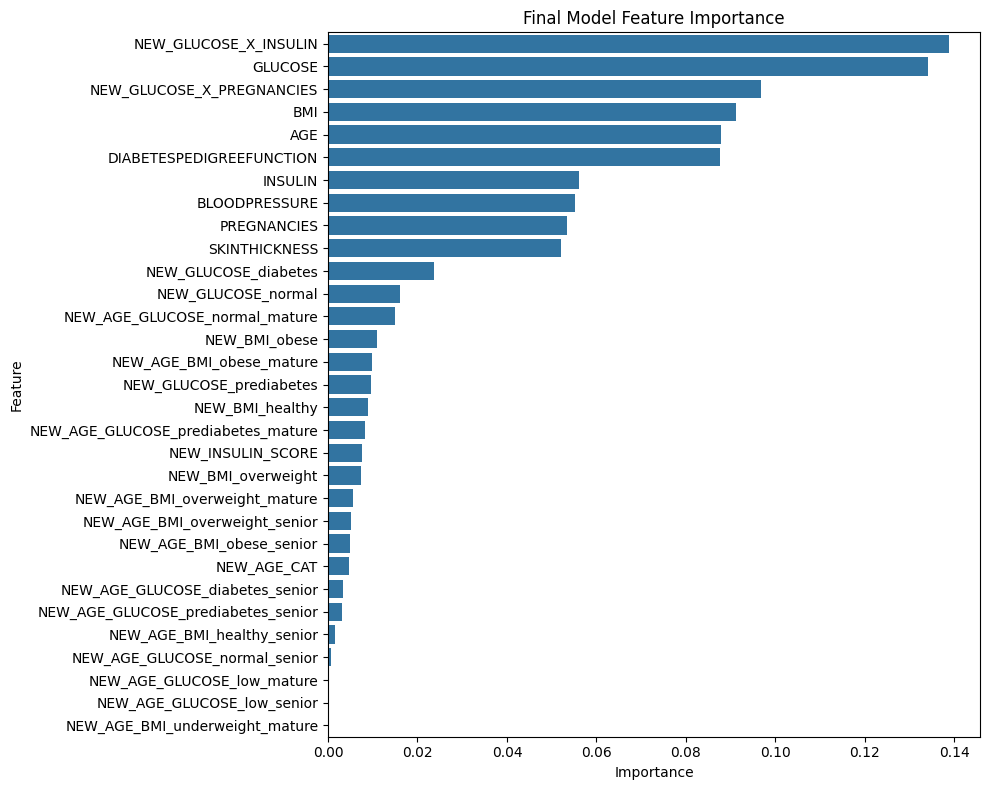

In [60]:
plot_importance(rf_model, X)

## Project Overview

The engineered features improved the model's overall accuracy and introduced meaningful interaction variables. In particular, interaction features such as `NEW_GLUCOSE_X_INSULIN` and `NEW_GLUCOSE_X_PREGNANCIES` became some of the most influential predictors in the final model, demonstrating the value of domain-driven feature engineering.

Overall, this project highlights how thoughtful preprocessing and feature engineering can enhance the predictive capability and interpretability of machine learning models.